<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Марат! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span> 

# Проект для "Викишоп" без BERT

## Описание проекта

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.
Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.
Постройте модель со значением метрики качества **F1 не меньше 0.75**.

## Подключение библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re 
import nltk

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import f1_score
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', None)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Но их лучше собрать в одной ячейке и разделить на функциональные группы пустой строкой.</font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Исправил

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> 👍</span>

## Подготовка данных

In [2]:
try:
    df = pd.read_csv('toxic_comments.csv')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv')

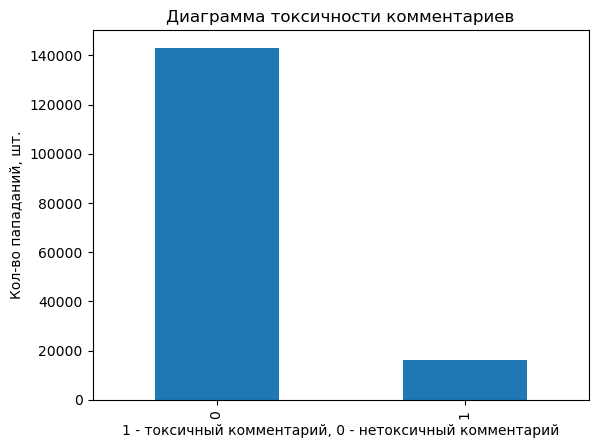

In [3]:
df['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова. Ещё такой <a href='https://github.com/Dyakonov/ml_hacks/blob/master/book_disbalance_public_v1.ipynb'>ноутбук</a> есть.</font>

Обнаружен дисбаланс, устраним его позже

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Мы не можем балансировать весь датасет, поскольку в этом случае мы балансируем также тестовую выборку. С такой тестовой выборкой метрика не сможет адекватно оценить работу модели на входящих данных с реальным распределением таргетов.~~ </font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Исправил. Согласно теории это можно сделать через ImbPipeline, он устраняет дисбаланс только у трейна, а валид не трогает

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<span style="color: green"> Верно, можно применять балансировщики из библиотеки `imblearn` объединённые с классификатором в Pipeline.</span>

In [4]:
df.head(1)

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0


Комментарии на англ. языке

In [5]:
df = df[['text', 'toxic']]

In [6]:
df.head(1)

,text,toxic
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Для этой задачи существуют специальные модели, например 'unitary/toxic-bert'</font>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Но это готовый классификатор, а мне его использовать нельзя

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Верно, что подрезаешь вектор токенов в Токенизаторе.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> Это лишнее.</span>

<span style="color: purple; font-weight: bold">Комментарий студента</span><br>
Это я проверяю алгоритмы для себя)

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Для этой задачи существуют специальные модели, например 'unitary/toxic-bert'</font>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='darkorange'> Обрати внимание на отступы. По стандарту должно быть 4 пробела. Такой код будет работать не везде. В Колабе можно настроить автоматическое добавление отступов как 4 пробела.</font>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'>Здорово, что есть вариативность по процессорам.</font>

<font color='green'>
Если, обучать BERT на GPU (можно в Google Colab или Kaggle), то должно быть побыстрее.

<font color='green'>Пример BERT с GPU:
```python
%%time
from tqdm import notebook
batch_size = 2 # для примера возьмем такой батч, где будет всего две строки датасета
embeddings = []
model.cuda()   # закидываем модель на GPU
for i in notebook.tqdm(range(input_ids.shape[0] // batch_size)):
        batch = torch.LongTensor(input_ids[batch_size*i:batch_size*(i+1)]).cuda() # закидываем тензор на GPU
        attention_mask_batch = torch.LongTensor(attention_mask[batch_size*i:batch_size*(i+1)]).cuda()

        with torch.no_grad():
            batch_embeddings = model(batch, attention_mask=attention_mask_batch)

        embeddings.append(batch_embeddings[0][:,0,:].cpu().numpy()) # перевод обратно на проц, чтобы в нумпай кинуть
        del batch
        del attention_mask_batch
        del batch_embeddings

features = np.concatenate(embeddings)
```
НО нужно сделать предварительную проверку на наличие GPU.\
Например, так: ```device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")```\
Тогда вместо .cuda() нужно писать .to(device)

</font>

Приведем весь текст к нижнему регистру

In [8]:
df['text'] = df['text'].str.lower()
df.head(1)

,text,toxic
0,"explanation\nwhy the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27",0


In [9]:
nltk.download('wordnet')
nltk.download('punkt_tab') #для токенизации
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Marat\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Marat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
def prepare_text(text):
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = text.split()
    text = " ".join(text)
    tokens = nltk.word_tokenize(text)
    text = [lemmatizer.lemmatize(t) for t in tokens]
    text = " ".join(text)
    return text

In [11]:
df['prepare_text'] = df['text'].apply(prepare_text)

In [12]:
df.head(3)

,text,toxic,prepare_text
0,"explanation\nwhy the edits made under my username hardcore metallica fan were reverted? they weren't vandalisms, just closure on some gas after i voted at new york dolls fac. and please don't remove the template from the talk page since i'm retired now.89.205.38.27",0,explanation why the edits made under my username hardcore metallica fan were reverted they weren t vandalism just closure on some gas after i voted at new york doll fac and please don t remove the template from the talk page since i m retired now
1,"d'aww! he matches this background colour i'm seemingly stuck with. thanks. (talk) 21:51, january 11, 2016 (utc)",0,d aww he match this background colour i m seemingly stuck with thanks talk january utc
2,"hey man, i'm really not trying to edit war. it's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. he seems to care more about the formatting than the actual info.",0,hey man i m really not trying to edit war it s just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info


## Построение предсказательных моделей

In [13]:
train, test = train_test_split(df[['prepare_text', 'toxic']], random_state=RANDOM_STATE, stratify=df['toxic'])

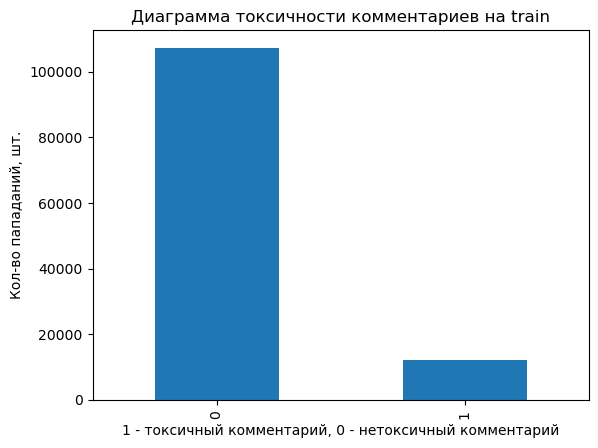

In [14]:
train['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев на train')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

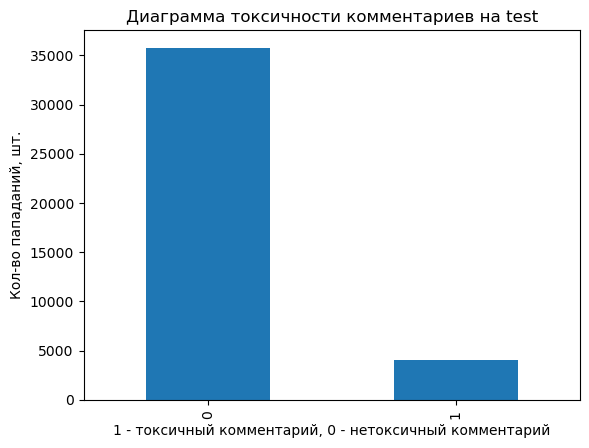

In [15]:
test['toxic'].value_counts().plot(kind='bar')
plt.title('Диаграмма токсичности комментариев на test')
plt.xlabel('1 - токсичный комментарий, 0 - нетоксичный комментарий')
plt.ylabel('Кол-во пападаний, шт.')
plt.show()

In [16]:
nltk.download('stopwords')
stopwords = list(nltk_stopwords.words('english'))
count_tf_idf = TfidfVectorizer(stop_words=stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Marat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
train_tf_idf = count_tf_idf.fit_transform(train['prepare_text'])

In [18]:
test_tf_idf = count_tf_idf.transform(test['prepare_text'])

In [19]:
pipe_final = ImbPipeline(
    [
        ('rUS', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [20]:
param_grid = [
    #{
    #    'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)]
    #},
    
    #{
    #    'models': [LogisticRegression(random_state=RANDOM_STATE)]
    #},

    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'models__kernel': ['rbf', 'linear', 'poly'],
        'models__degree': range(2, 3)
    }
]

In [21]:
grid_search = GridSearchCV(
    pipe_final,
    param_grid,
    n_jobs=-1,
    scoring='f1'
)

In [22]:
grid_search.fit(train_tf_idf, train['toxic'])

GridSearchCV(estimator=Pipeline(steps=[('rUS',
                                        RandomUnderSampler(random_state=42)),
                                       ('models',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'models': [SVC(random_state=42)],
                          'models__degree': range(2, 3),
                          'models__kernel': ['rbf', 'linear', 'poly']}],
             scoring='f1')

In [23]:
pd.DataFrame(grid_search.cv_results_)[['rank_test_score', 'mean_test_score','params']]

,rank_test_score,mean_test_score,params
0,1,0.712031,"{'models': SVC(random_state=42), 'models__degree': 2, 'models__kernel': 'rbf'}"
1,3,0.694254,"{'models': SVC(random_state=42), 'models__degree': 2, 'models__kernel': 'linear'}"
2,2,0.711614,"{'models': SVC(random_state=42), 'models__degree': 2, 'models__kernel': 'poly'}"


In [24]:
f1_best = grid_search.best_score_

In [25]:
print('Среднее значение метрики F1 на валидационной выборке', f1_best)

Среднее значение метрики F1 на валидационной выборке 0.712031113223215


Для устранения дисбаланса попробуем применить балансировку весов вместо RandomUnderSampler

In [26]:
model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', C=10)

In [27]:
scores = cross_val_score(model, train_tf_idf, train['toxic'], cv=5, scoring='f1')

In [28]:
print('Среднее значение метрики F1 на валидационной выборке', scores.mean())

Среднее значение метрики F1 на валидационной выборке 0.7611965016455036


In [29]:
model.fit(train_tf_idf, train['toxic'])

LogisticRegression(C=10, class_weight='balanced', random_state=42)

In [30]:
f1_test = f1_score(test['toxic'], model.predict(test_tf_idf))

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

In [31]:
print('Среднее значение метрики F1 на тестовой выборке', f1_test)

Среднее значение метрики F1 на тестовой выборке 0.7585096596136155


<font color='blue'><b>Комментарий ревьюера 2: </b></font> \
<font color='blue'> Что можно попробовать сделать:
- Другие методы векторизации текста (TfIdf)
- Обучить полный классификатор с BERT на PyTorch
- Применить специализированные предобученые модели.</font>

## Вывод

Классификацию на BERT нельзя признать удачной, так как даже при использовании полного датафрейма F1 < 0.66 при 1.5 часовой работе в Колаб. При использовании Tfid с предварительной обработкой (приведение текста к нижнему регистру, лемматизация) метрика > 0.75, что соответствует требованию Заказчика

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Очень приятно видеть вывод в конце проекта! В выводах можно приводить полученные ранее значения. Также можно расписать все, что было сделано в ходе проведения работы. Представь, что тебе заплатят исходя из объёма сделанных тобой выводов )).</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Марат, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
</font>

<font color='blue'>Что нужно исправить:</font>
<ul><font color='red'>Не балансируй тестовые и валидационные данные.</font></ul>

<font color='blue'>Что можно сделать лучше:</font>
<font color='orange'>В работе я оставил несколько советов. Буду рад, если ты учтешь их.</font></ul>

<font color='blue'><b>Жду новую версию проекта :)</b></font>

<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'>Марат, большое спасибо за доработку.
</font>

<font color='blue'>Что нужно исправить:</font>
<ul><font color='red'>Построй модель со значением метрики качества F1 не меньше 0.75 на тестовых данных.</font></ul>

<font color='blue'>Что можно сделать лучше:</font>
<font color='orange'>В работе я оставил несколько советов. Буду рад, если ты учтешь их.</font></ul>

<font color='blue'><b>Жду новую версию проекта :)</b></font>